# 02 - EDA, WOE & IV

- Data profiling: missing value, phan bo bien, outlier
- Data cleaning: xu ly missing/outlier, encode categorical
- Univariate + bivariate voi loan_status
- Tinh WOE/IV cho tung bien ung vien

In [1]:
import sys
from pathlib import Path
sys.path.append(str(Path.cwd().parent))

import pandas as pd
from src.paths import DATA_RAW, DATA_INTERIM, DATA_PROCESSED, MODELS, REPORTS_FIGURES

## Data profiling

In [2]:
import numpy as np

accepted = pd.read_parquet(DATA_INTERIM / 'accepted_vintage_2015_2017.parquet')

# grade/sub_grade/int_rate bi loai khoi feature du bao: day la KET QUA tu underwriting
# noi bo cua LC (LC tu cham grade roi gan int_rate theo grade), khong phai dac diem tho
# cua khach hang. Dua vao lam predictor se khien model chu yeu hoc lai grade cua LC thay
# vi danh gia rui ro doc lap. int_rate duoc giu rieng, chi dung tinh Expected Net Return
# o notebook 05.
CANDIDATE_FEATURES = [
    'loan_amnt', 'term', 'emp_length', 'home_ownership', 'annual_inc', 'purpose',
    'dti', 'delinq_2yrs', 'earliest_cr_line', 'fico_range_low', 'fico_range_high',
    'inq_last_6mths', 'open_acc', 'pub_rec', 'revol_bal', 'revol_util', 'total_acc',
    'addr_state',
]
TARGET = 'loan_status'
PRICING_COLS = ['int_rate', 'grade']

df = accepted[CANDIDATE_FEATURES + PRICING_COLS + [TARGET, 'issue_d']].copy()
df['bad_flag'] = (df[TARGET] == 'Charged Off').astype(int)

print('shape:', df.shape)
print('bad rate:', df['bad_flag'].mean().round(4))

missing_pct = df.isna().mean().sort_values(ascending=False) * 100
print('\nMissing %:')
print(missing_pct[missing_pct > 0])

print('\nterm unique (ky vong hang so sau khi loc vintage 36 thang):', df['term'].unique())

numeric_cols = df.select_dtypes('number').columns.drop('bad_flag')
df[numeric_cols].describe().T


shape: (643917, 23)
bad rate: 0.177

Missing %:
emp_length    7.026527
revol_util    0.063362
dti           0.023916
dtype: float64

term unique (ky vong hang so sau khi loc vintage 36 thang): <ArrowStringArray>
[' 36 months']
Length: 1, dtype: str


,count,mean,std,min,25%,50%,75%,max
loan_amnt,643917.0,12725.224136,8401.410514,1000.00,6075.00,10000.00,17000.00,40000.00
annual_inc,643917.0,75764.190106,76088.203627,0.00,45000.00,63000.00,90000.00,10999200.00
dti,643763.0,18.478239,11.093486,-1.00,11.82,17.76,24.46,999.00
delinq_2yrs,643917.0,0.347796,0.935454,0.00,0.00,0.00,0.00,30.00
fico_range_low,643917.0,695.374280,32.175544,660.00,670.00,685.00,710.00,845.00
fico_range_high,643917.0,699.374454,32.176356,664.00,674.00,689.00,714.00,850.00
inq_last_6mths,643917.0,0.582365,0.874441,0.00,0.00,0.00,1.00,6.00
open_acc,643917.0,11.602705,5.631468,0.00,8.00,11.00,14.00,82.00
pub_rec,643917.0,0.253950,0.667820,0.00,0.00,0.00,0.00,86.00
revol_bal,643917.0,15657.064320,23321.532444,0.00,5430.00,10163.00,18383.00,2904836.00


## Data cleaning

In [3]:
from src.features.clean import engineer_features, winsorize

# emp_length -> nam, credit_history_length tu earliest_cr_line, winsorize annual_inc/dti/revol_bal
# tai 1st/99th percentile (ham dung chung src/features/clean.py, tai su dung o notebook 03 voi
# bounds tinh tren train de tranh leakage nguong cat giua cac tap. O day fit tren toan bo tap vi
# day la buoc EDA, chua phai tap dung de train model chinh thuc).
df = engineer_features(df)
df, _bounds = winsorize(df)
CANDIDATE_FEATURES = [c for c in CANDIDATE_FEATURES if c not in ('term', 'emp_length', 'earliest_cr_line')]
CANDIDATE_FEATURES += ['emp_length_years', 'credit_history_length']

print('Missing % sau cleaning:')
print(df[CANDIDATE_FEATURES].isna().mean().sort_values(ascending=False).head(10) * 100)
print()
df[['annual_inc', 'dti', 'revol_bal', 'revol_util', 'emp_length_years', 'credit_history_length']].describe().T


Missing % sau cleaning:
emp_length_years    7.026527
revol_util          0.063362
dti                 0.023916
loan_amnt           0.000000
home_ownership      0.000000
delinq_2yrs         0.000000
fico_range_low      0.000000
annual_inc          0.000000
purpose             0.000000
inq_last_6mths      0.000000
dtype: float64



,count,mean,std,min,25%,50%,75%,max
annual_inc,643917.0,74006.245394,43992.086863,16920.00,45000.00,63000.00,90000.00,266000.00
dti,643763.0,18.346871,8.607038,1.89,11.82,17.76,24.46,38.83
revol_bal,643917.0,14892.566972,15756.286006,178.00,5430.00,10163.00,18383.00,99521.52
revol_util,643509.0,49.612453,24.412538,0.00,31.10,49.10,68.00,193.00
emp_length_years,598672.0,5.863528,3.729046,0.00,2.00,6.00,10.00,10.00
credit_history_length,643917.0,196.491936,92.865182,37.00,134.00,178.00,244.00,999.00


## Univariate / bivariate analysis

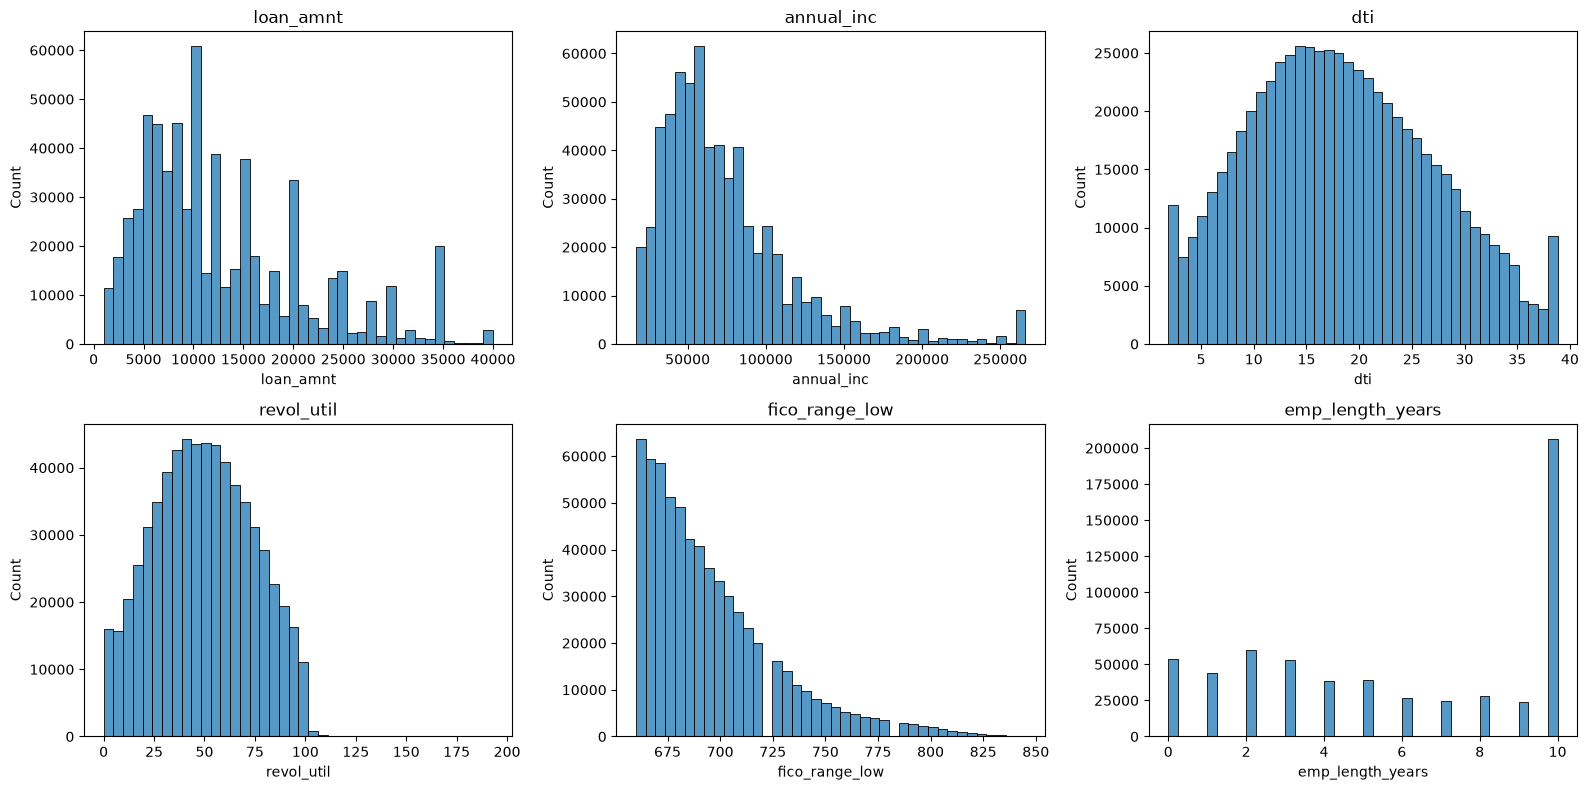

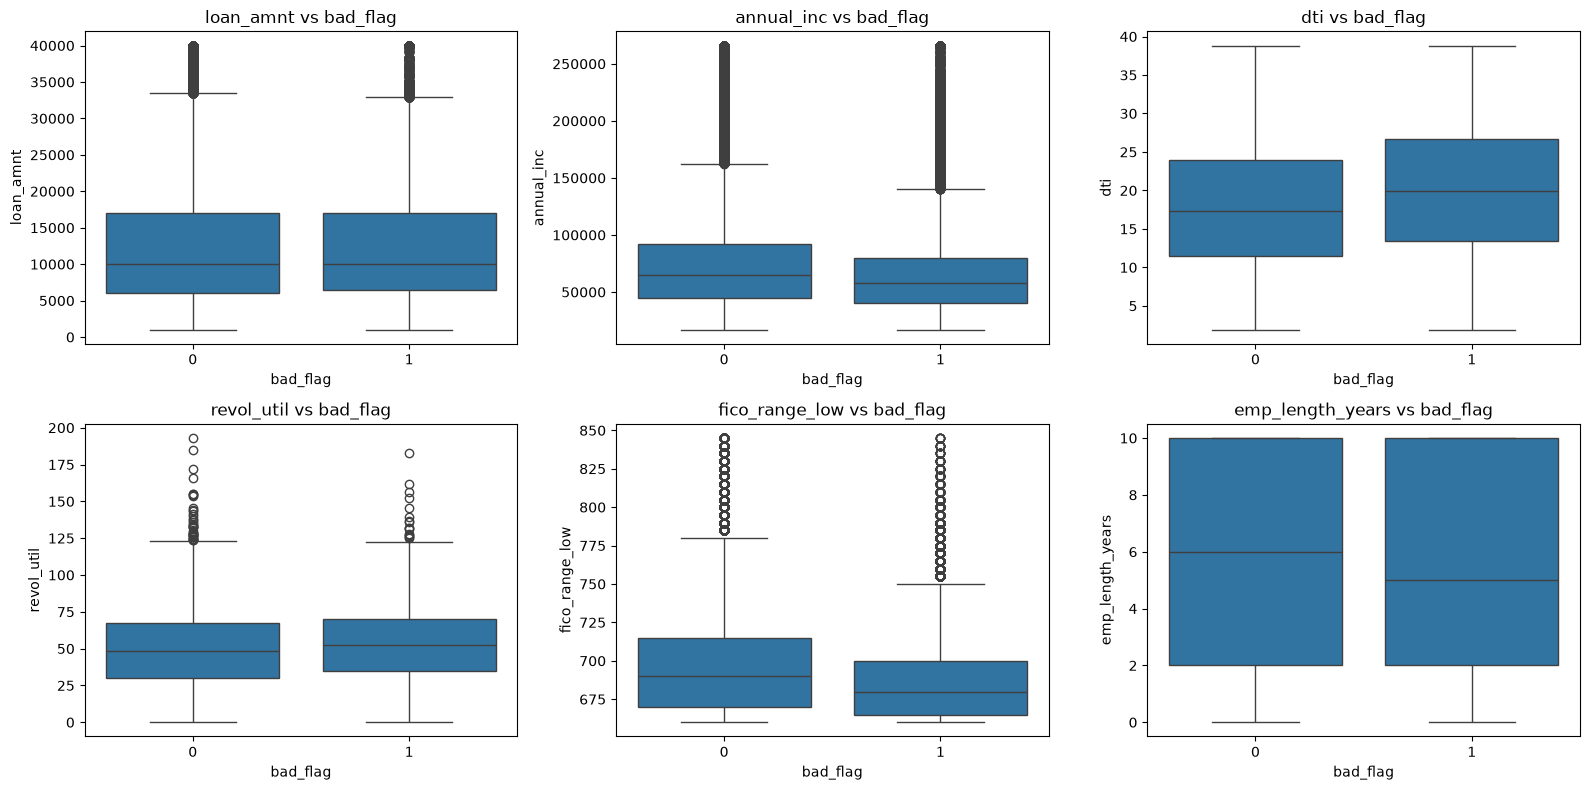

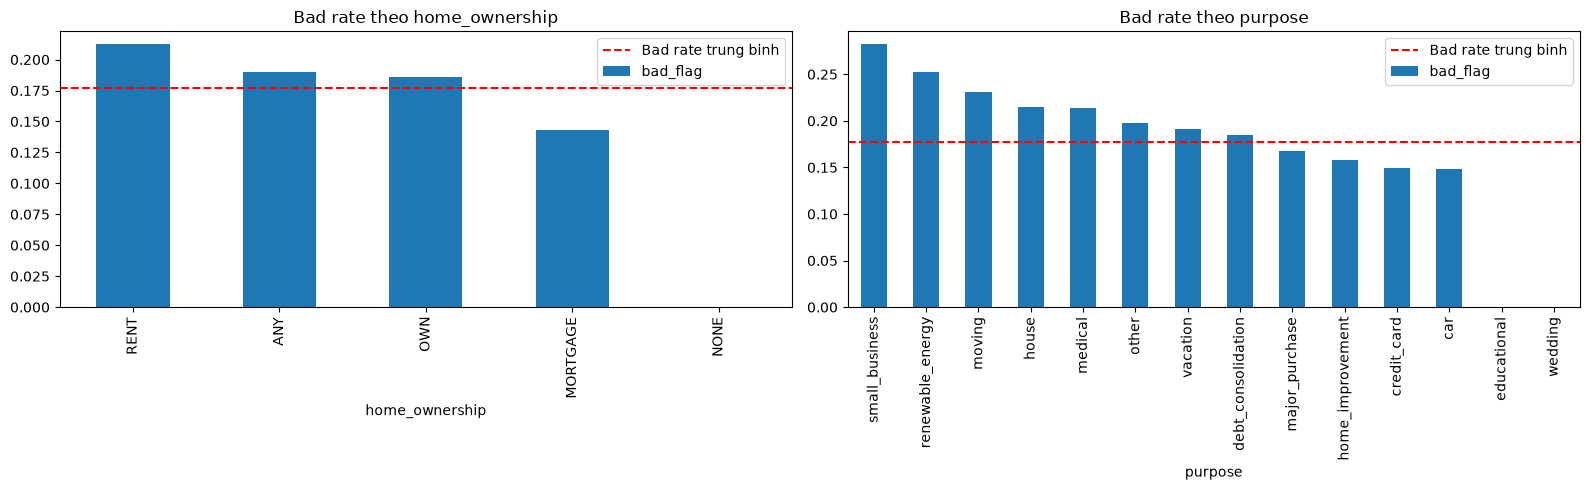

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

REPORTS_FIGURES.mkdir(parents=True, exist_ok=True)

numeric_plot_cols = ['loan_amnt', 'annual_inc', 'dti', 'revol_util', 'fico_range_low', 'emp_length_years']

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, col in zip(axes.flat, numeric_plot_cols):
    sns.histplot(df[col].dropna(), bins=40, ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.savefig(REPORTS_FIGURES / 'univariate_numeric.png', dpi=100)
plt.show()

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, col in zip(axes.flat, numeric_plot_cols):
    sns.boxplot(data=df, x='bad_flag', y=col, ax=ax)
    ax.set_title(f'{col} vs bad_flag')
plt.tight_layout()
plt.savefig(REPORTS_FIGURES / 'bivariate_numeric_vs_bad.png', dpi=100)
plt.show()

cat_cols = ['home_ownership', 'purpose']
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
for ax, col in zip(axes, cat_cols):
    rate = df.groupby(col)['bad_flag'].mean().sort_values(ascending=False)
    rate.plot(kind='bar', ax=ax)
    ax.set_title(f'Bad rate theo {col}')
    ax.axhline(df['bad_flag'].mean(), color='red', linestyle='--', label='Bad rate trung binh')
    ax.legend()
plt.tight_layout()
plt.savefig(REPORTS_FIGURES / 'bivariate_categorical_vs_bad.png', dpi=100)
plt.show()


## WOE / IV

In [5]:
from optbinning import BinningProcess

# WOE/IV o day la buoc EDA/xep hang bien (RQ1) tren toan bo tap vintage - CHUA phai binning
# dung de train model chinh thuc. O notebook 03, binning se duoc fit lai CHI TREN tap train
# (sau time-based split) de tranh leak thong tin tuong lai vao bien bin edges.
numeric_features = [c for c in CANDIDATE_FEATURES if pd.api.types.is_numeric_dtype(df[c])]
categorical_features = [c for c in CANDIDATE_FEATURES if c not in numeric_features]
print('numeric:', numeric_features)
print('categorical:', categorical_features)

binning_process = BinningProcess(
    variable_names=CANDIDATE_FEATURES,
    categorical_variables=categorical_features,
)
X = df[CANDIDATE_FEATURES]
y = df['bad_flag']
binning_process.fit(X, y)

iv_table = binning_process.summary().sort_values('iv', ascending=False).reset_index(drop=True)
iv_table


numeric: ['loan_amnt', 'annual_inc', 'dti', 'delinq_2yrs', 'fico_range_low', 'fico_range_high', 'inq_last_6mths', 'open_acc', 'pub_rec', 'revol_bal', 'revol_util', 'total_acc', 'emp_length_years', 'credit_history_length']
categorical: ['home_ownership', 'purpose', 'addr_state']


,name,dtype,status,selected,n_bins,iv,js,gini,quality_score
0,fico_range_low,numerical,OPTIMAL,True,13,0.147485,0.018014,0.200555,0.429942
1,fico_range_high,numerical,OPTIMAL,True,13,0.147485,0.018014,0.200555,0.429942
2,dti,numerical,OPTIMAL,True,14,0.061396,0.007637,0.140516,0.130429
3,annual_inc,numerical,OPTIMAL,True,14,0.053465,0.006647,0.130324,0.047783
4,home_ownership,categorical,OPTIMAL,True,3,0.050719,0.006325,0.11726,0.156408
5,inq_last_6mths,numerical,OPTIMAL,True,3,0.042609,0.005304,0.103651,0.120821
6,emp_length_years,numerical,OPTIMAL,True,6,0.026422,0.003276,0.072535,0.041701
7,revol_util,numerical,OPTIMAL,True,12,0.024661,0.003073,0.082516,0.032741
8,credit_history_length,numerical,OPTIMAL,True,11,0.019203,0.002396,0.076744,0.002132
9,addr_state,categorical,OPTIMAL,True,10,0.018976,0.002365,0.07208,0.027349


In [6]:
# Shortlist bien co suc manh du bao (IV > 0.02 - nguong chuan trong credit scoring, Siddiqi 2006:
# <0.02 khong huu ich, 0.02-0.1 yeu, 0.1-0.3 trung binh, 0.3-0.5 manh, >0.5 nghi ngo qua manh/leakage)
IV_THRESHOLD = 0.02
shortlist = iv_table.loc[iv_table['iv'] > IV_THRESHOLD, 'name'].tolist()
print(f'{len(shortlist)}/{len(CANDIDATE_FEATURES)} bien vuot nguong IV > {IV_THRESHOLD}:')
print(shortlist)

suspect = iv_table.loc[iv_table['iv'] > 0.5, 'name'].tolist()
if suspect:
    print(f'\nCANH BAO - IV > 0.5, kiem tra lai co phai leakage khong: {suspect}')

REPORTS_FIGURES.mkdir(parents=True, exist_ok=True)
iv_table.to_csv(REPORTS_FIGURES / 'iv_table.csv', index=False)

DATA_INTERIM.mkdir(parents=True, exist_ok=True)
with open(DATA_INTERIM / 'shortlist_features.txt', 'w') as f:
    f.write('\n'.join(shortlist))
print('\nDa luu shortlist vao data/interim/shortlist_features.txt')


8/17 bien vuot nguong IV > 0.02:
['fico_range_low', 'fico_range_high', 'dti', 'annual_inc', 'home_ownership', 'inq_last_6mths', 'emp_length_years', 'revol_util']

Da luu shortlist vao data/interim/shortlist_features.txt


## RQ5 - Approval rate (tham khảo): accepted vs. rejected

Reject Stats và Accepted Loans **không cùng schema** (`Risk_Score` xấp xỉ FICO vs. `fico_range_low/high`) —
xem PROPOSAL.md mục 4.3. Approval rate ước tính dưới đây chỉ mang tính xấp xỉ, không phải reject-inference
chuẩn xác.

In [7]:
rejected = pd.read_parquet(DATA_INTERIM / 'rejected_vintage_2015_2017.parquet')

n_accepted = len(accepted)
n_rejected = len(rejected)
approx_approval_rate = n_accepted / (n_accepted + n_rejected)
print(f'Accepted (vintage, truoc loc term/status): dung so goc truoc loc o notebook 01')
print(f'Rejected trong cung vintage window: {n_rejected:,}')
print(f'Approx approval rate = accepted / (accepted + rejected) = {approx_approval_rate:.2%}')
print('(Xap xi - accepted o day da bi loc them theo term=36 thang va loan_status, nen mau so')
print(' thuc te cua accepted truoc loc con lon hon -> approval rate thuc te se cao hon so tren.)')

fico_mid = (accepted['fico_range_low'] + accepted['fico_range_high']) / 2
comparison = pd.DataFrame({
    'accepted_fico_mid': fico_mid.describe(),
    'rejected_risk_score': rejected['Risk_Score'].describe(),
})
comparison


Accepted (vintage, truoc loc term/status): dung so goc truoc loc o notebook 01
Rejected trong cung vintage window: 14,701,826
Approx approval rate = accepted / (accepted + rejected) = 4.20%
(Xap xi - accepted o day da bi loc them theo term=36 thang va loan_status, nen mau so
 thuc te cua accepted truoc loc con lon hon -> approval rate thuc te se cao hon so tren.)


,accepted_fico_mid,rejected_risk_score
count,643917.000000,5.355072e+06
mean,697.374367,6.340825e+02
std,32.175950,6.479658e+01
min,662.000000,3.000000e+02
25%,672.000000,5.930000e+02
50%,687.000000,6.360000e+02
75%,712.000000,6.730000e+02
max,847.500000,9.900000e+02
